In [2]:
import cv2
import matplotlib.pyplot as plt

In [3]:
def show(image):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)

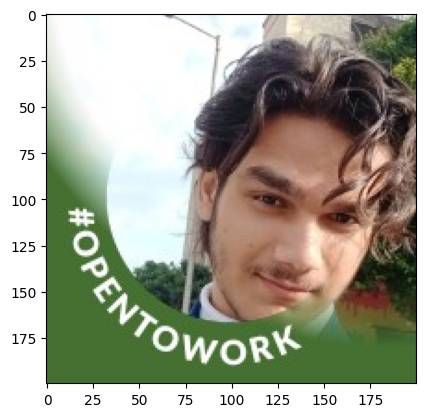

In [4]:
image = cv2.imread("linked profile.jpg")
show(image)

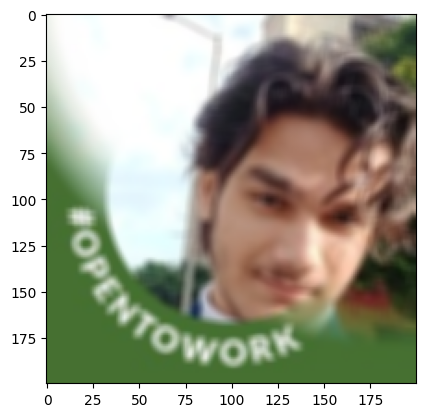

In [5]:
image_gaus = cv2.GaussianBlur(image, (5,5), 10)
show(image_gaus)

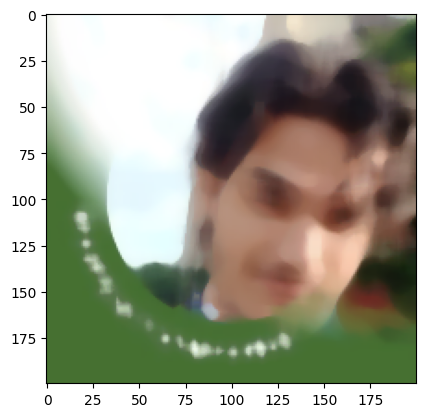

In [6]:
image_med = cv2.medianBlur(image, 11)
show(image_med)

In [7]:
import numpy as np
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0],
])

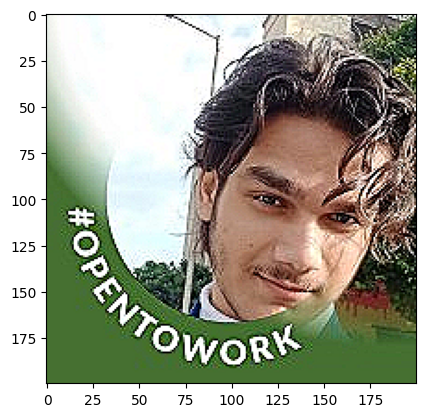

In [8]:
image_sharp = cv2.filter2D(image, -1, sharpen_kernel)
show(image_sharp)

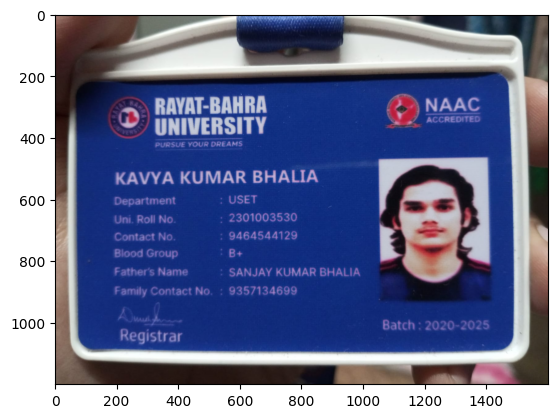

In [9]:
id = cv2.imread("ID card.jpeg")
show(id)

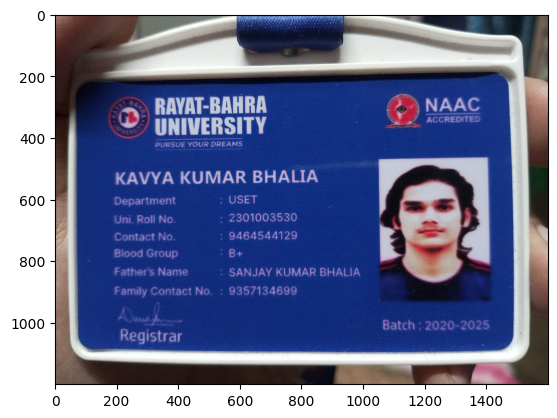

In [10]:
id_sharpen = cv2.filter2D(id, -1, sharpen_kernel)
show(id_sharpen)

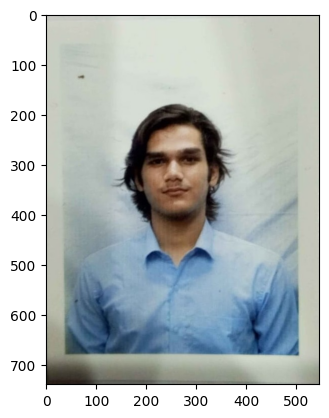

In [11]:
passport = cv2.imread("college photo.jpg")
show(passport)

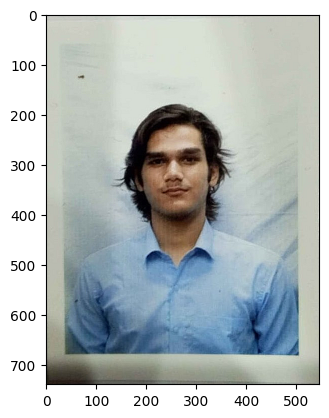

In [12]:
passport_sharp = cv2.filter2D(passport, -1, sharpen_kernel)
show(passport_sharp)

In [13]:
img = cv2.imread("college photo.jpg", cv2.IMREAD_GRAYSCALE)

# WRONG for Sobel: Using ddepth = -1 clips negative slopes to 0 (loses edges!)
sobel_wrong = cv2.Sobel(img, ddepth=-1, dx=1, dy=0)

# CORRECT for Sobel: Use 64-bit float to preserve negative slopes, then take absolute value
sobel_float = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=1, dy=0)
sobel_correct = np.uint8(np.absolute(sobel_float)) # Convert back to uint8 for display

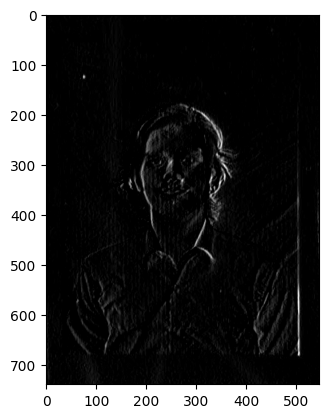

In [14]:
show(sobel_wrong)

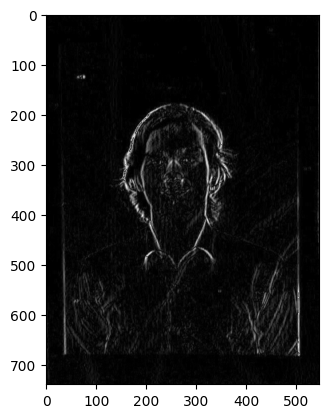

In [15]:
show(sobel_correct)

In [16]:
img = cv2.imread("ID card.jpeg", cv2.IMREAD_GRAYSCALE)

# WRONG for Sobel: Using ddepth = -1 clips negative slopes to 0 (loses edges!)
sobel_wrong = cv2.Sobel(img, ddepth=-1, dx=1, dy=0)

# CORRECT for Sobel: Use 64-bit float to preserve negative slopes, then take absolute value
sobel_float = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=1, dy=0)
sobel_correct = np.uint8(np.absolute(sobel_float)) # Convert back to uint8 for display

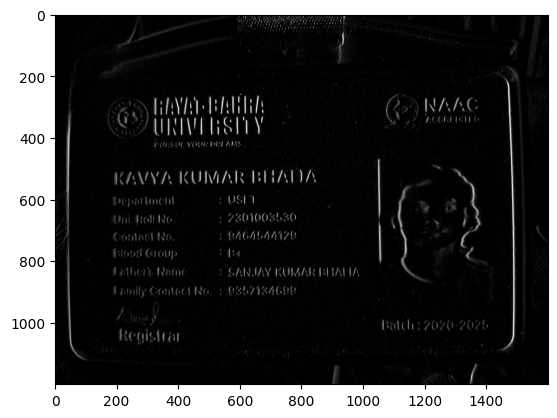

In [17]:
show(sobel_wrong)

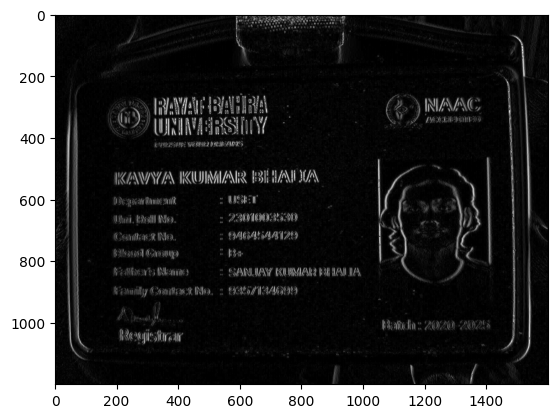

In [18]:
show(sobel_correct)

### Canny Edge Detection

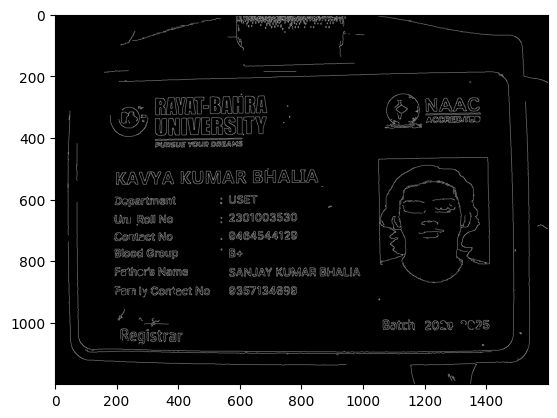

In [46]:
id_gray = cv2.cvtColor(id, cv2.COLOR_BGR2GRAY)
id_edge = cv2.Canny(id_gray, 50, 150)
plt.imshow(id_edge, cmap = 'gray')

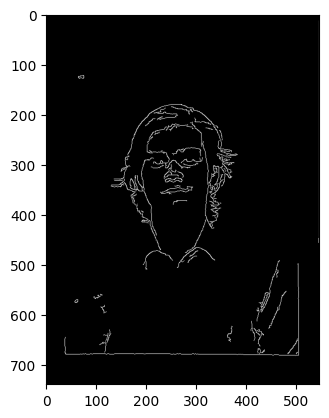

In [48]:
passport_gray = cv2.cvtColor(passport, cv2.COLOR_BGR2GRAY)
passport_edge = cv2.Canny(passport_gray, 50, 150)
plt.imshow(passport_edge, cmap = 'gray')

### Gemini Suggested dynamic canny threshold on the bases of median of image

In [51]:
def auto_canny(image, sigma = 0.33):
    v = np.median(image)

    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))

    edged = cv2.Canny(image, lower, upper)
    return edged

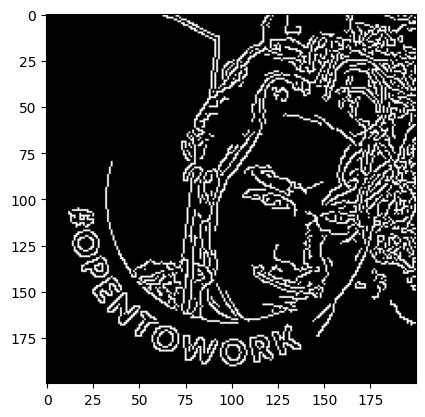

In [53]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_edge = auto_canny(image_gray)
plt.imshow(image_edge, cmap = 'gray')

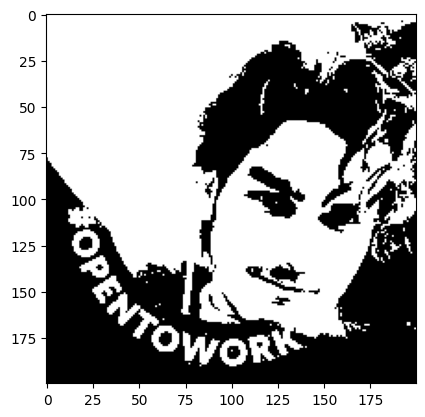

In [67]:
ret, image_thresh = cv2.threshold(image_gray, 100, 255, cv2.THRESH_BINARY)
plt.imshow(image_thresh, cmap = 'gray')

### Gemini suggested Automatic Threshold Otsu method

Otsu automatically selected threshold value: 163.0


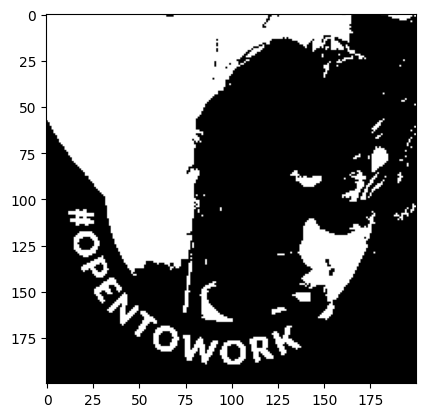

In [76]:
ret_otsu, thresh_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Otsu automatically selected threshold value: {ret_otsu}")
plt.imshow(thresh_otsu, cmap = 'gray')

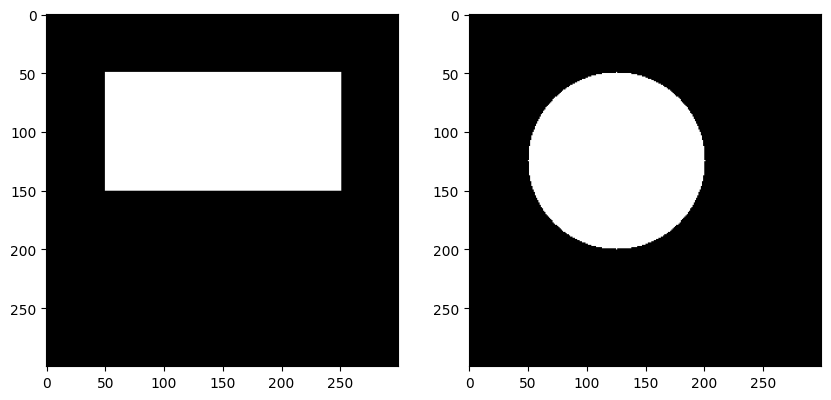

In [96]:
img1 = np.zeros((300, 300), dtype = 'uint8')
img2 = np.zeros((300, 300), dtype = 'uint8')

img1 = cv2.rectangle(img1, (50, 50), (250, 150), 255, -1)
img2 = cv2.circle(img2, (125, 125), 75, 255, -1)

plt.figure(figsize = (10, 7))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap = 'gray')
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap = 'gray')

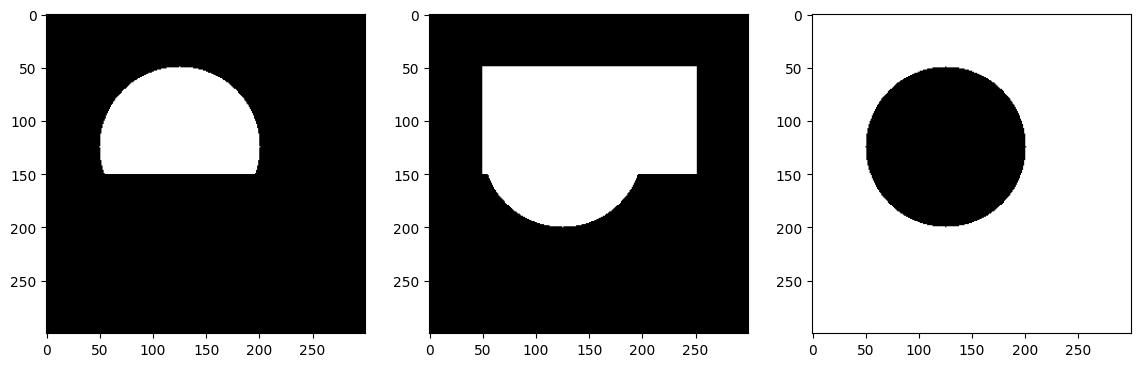

In [102]:
bit_and = cv2.bitwise_and(img1, img2)
bit_or = cv2.bitwise_or(img1, img2)
bit_not = cv2.bitwise_not(img2)

plt.figure(figsize = (14, 7))
plt.subplot(1, 3, 1)
plt.imshow(bit_and, cmap = 'gray')
plt.subplot(1, 3, 2)
plt.imshow(bit_or, cmap = 'gray')
plt.subplot(1, 3, 3)
plt.imshow(bit_not, cmap = 'gray')